# Telemetries C-MAPSS Data Extraction and Validation

This notebook prepares all four C-MAPSS subsets in one portable location:

```text
data/CMAPSSData/
  train_FD001.txt ... train_FD004.txt
  test_FD001.txt  ... test_FD004.txt
  RUL_FD001.txt   ... RUL_FD004.txt
```

It is safe to rerun\. Existing complete data is reused, and downloading occurs
only when required files are missing.


In [2]:
from pathlib import Path
import shutil
import urllib.request
import zipfile

import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = (
    "https://phm-datasets.s3.amazonaws.com/NASA/"
    "6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip"
)

DATA_ROOT = Path("data")
CMAPSS_DIR = DATA_ROOT / "CMAPSSData"
DOWNLOAD_PATH = DATA_ROOT / "cmapss_outer.zip"
EXTRACT_ROOT = DATA_ROOT / "_cmapss_extract"
SUBSETS = ("FD001", "FD002", "FD003", "FD004")

REQUIRED_FILES = [
    CMAPSS_DIR / f"{prefix}_{subset}.txt"
    for subset in SUBSETS
    for prefix in ("train", "test", "RUL")
]

print("Notebook working directory:", Path.cwd().resolve())
print("Canonical dataset directory:", CMAPSS_DIR.resolve())


Notebook working directory: /workspace/notebooks
Canonical dataset directory: /workspace/notebooks/data/CMAPSSData


In [3]:
def safe_extract(archive_path: Path, destination: Path) -> None:
    destination.mkdir(parents=True, exist_ok=True)
    destination_resolved = destination.resolve()

    with zipfile.ZipFile(archive_path) as archive:
        for member in archive.infolist():
            target = (destination / member.filename).resolve()
            if destination_resolved not in target.parents and target != destination_resolved:
                raise ValueError(f"Unsafe archive member: {member.filename}")
        archive.extractall(destination)


def dataset_is_complete() -> bool:
    return all(path.is_file() and path.stat().st_size > 0 for path in REQUIRED_FILES)


def find_extracted_dataset(root: Path) -> Path:
    matches = list(root.rglob("train_FD001.txt"))
    if not matches:
        raise FileNotFoundError("Could not locate train_FD001.txt after extraction.")

    for match in matches:
        candidate = match.parent
        expected = [
            candidate / f"{prefix}_{subset}.txt"
            for subset in SUBSETS
            for prefix in ("train", "test", "RUL")
        ]
        if all(path.is_file() for path in expected):
            return candidate

    raise FileNotFoundError("No extracted directory contains all 12 C-MAPSS files.")


In [4]:
DATA_ROOT.mkdir(parents=True, exist_ok=True)
CMAPSS_DIR.mkdir(parents=True, exist_ok=True)

if dataset_is_complete():
    print("C-MAPSS data is already complete. Download skipped.")
else:
    print("Required files are missing. Downloading C-MAPSS...")
    urllib.request.urlretrieve(DATA_URL, DOWNLOAD_PATH)
    print(f"Downloaded: {DOWNLOAD_PATH}")

    safe_extract(DOWNLOAD_PATH, EXTRACT_ROOT)

    nested_archives = list(EXTRACT_ROOT.rglob("CMAPSSData.zip"))
    for nested_archive in nested_archives:
        nested_destination = nested_archive.parent / "CMAPSSData_extracted"
        safe_extract(nested_archive, nested_destination)

    source_dir = find_extracted_dataset(EXTRACT_ROOT)
    for source_path in source_dir.glob("*.txt"):
        if source_path.name.startswith(("train_", "test_", "RUL_")):
            shutil.copy2(source_path, CMAPSS_DIR / source_path.name)

    print(f"Normalized C-MAPSS files into: {CMAPSS_DIR.resolve()}")

if not dataset_is_complete():
    missing = [str(path) for path in REQUIRED_FILES if not path.is_file()]
    raise RuntimeError(f"Data preparation failed. Missing files: {missing}")


Required files are missing. Downloading C-MAPSS...
Downloaded: data/cmapss_outer.zip
Normalized C-MAPSS files into: /workspace/notebooks/data/CMAPSSData


In [5]:
validation_rows = []

for path in REQUIRED_FILES:
    first_line = path.read_text(encoding="utf-8").splitlines()[0].split()
    expected_columns = 1 if path.name.startswith("RUL_") else 26
    actual_columns = len(first_line)

    validation_rows.append(
        {
            "file": path.name,
            "size_mb": round(path.stat().st_size / (1024 ** 2), 3),
            "columns": actual_columns,
            "expected_columns": expected_columns,
            "valid": actual_columns == expected_columns,
        }
    )

validation = pd.DataFrame(validation_rows)
display(validation)

if not validation["valid"].all():
    raise ValueError("One or more C-MAPSS files failed column validation.")

print("Data extraction and file validation completed successfully.")


,file,size_mb,columns,expected_columns,valid
0,train_FD001.txt,3.353,26,26,True
1,test_FD001.txt,2.126,26,26,True
2,RUL_FD001.txt,0.000,1,1,True
3,train_FD002.txt,8.662,26,26,True
4,test_FD002.txt,5.469,26,26,True
5,RUL_FD002.txt,0.001,1,1,True
6,train_FD003.txt,4.019,26,26,True
7,test_FD003.txt,2.696,26,26,True
8,RUL_FD003.txt,0.000,1,1,True
9,train_FD004.txt,9.871,26,26,True


Data extraction and file validation completed successfully.


## Load and Summarize All Subsets

Training and test telemetry have 26 columns: engine unit, cycle, three
operational settings, and 21 sensors. Official test RUL files contain one value
per test engine.


In [6]:
COLUMNS = (
    ["unit", "cycle"]
    + [f"op_setting_{index}" for index in range(1, 4)]
    + [f"sensor_{index}" for index in range(1, 22)]
)


def load_telemetry(split: str, subset: str) -> pd.DataFrame:
    path = CMAPSS_DIR / f"{split}_{subset}.txt"
    return pd.read_csv(path, sep=r"\s+", header=None, names=COLUMNS)


def load_test_rul(subset: str) -> pd.Series:
    path = CMAPSS_DIR / f"RUL_{subset}.txt"
    return pd.read_csv(path, sep=r"\s+", header=None, names=["RUL"])["RUL"]


In [10]:
summary_rows = []

for subset in SUBSETS:
    train = load_telemetry("train", subset)
    test = load_telemetry("test", subset)
    test_rul = load_test_rul(subset)

    if test["unit"].nunique() != len(test_rul):
        raise ValueError(
            f"{subset}: test engine count does not match official RUL labels."
        )

    summary_rows.append(
        {
            "subset": subset,
            "train_rows": len(train),
            "train_engines": train["unit"].nunique(),
            "test_rows": len(test),
            "test_engines": test["unit"].nunique(),
            "RUL_labels": len(test_rul),
            "missing_values": int(train.isna().sum().sum() + test.isna().sum().sum()),
        }
    )

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)
print("All four subsets loaded and cross-checked successfully.")


,subset,train_rows,train_engines,test_rows,test_engines,RUL_labels,missing_values
0,FD001,20631,100,13096,100,100,0
1,FD002,53759,260,33991,259,259,0
2,FD003,24720,100,16596,100,100,0
3,FD004,61249,249,41214,248,248,0


All four subsets loaded and cross-checked successfully.


## FD001 Sanity Check

Some FD001 sensors are constant by design. Plot a varying sensor such as
`sensor_4`; plotting `sensor_1` produces a straight line because its value is
always 518.67 in FD001.


In [8]:
train_fd001 = load_telemetry("train", "FD001")
test_fd001 = load_telemetry("test", "FD001")
rul_fd001 = load_test_rul("FD001")

max_cycles = train_fd001.groupby("unit")["cycle"].transform("max")
train_fd001["RUL"] = max_cycles - train_fd001["cycle"]

constant_columns = [
    column
    for column in COLUMNS[2:]
    if train_fd001[column].nunique(dropna=False) <= 1
]

print("FD001 training shape:", train_fd001.shape)
print("FD001 test shape:", test_fd001.shape)
print("FD001 official test RUL labels:", len(rul_fd001))
print("Constant FD001 feature columns:", constant_columns)
display(train_fd001.head())


FD001 training shape: (20631, 27)
FD001 test shape: (13096, 26)
FD001 official test RUL labels: 100
Constant FD001 feature columns: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


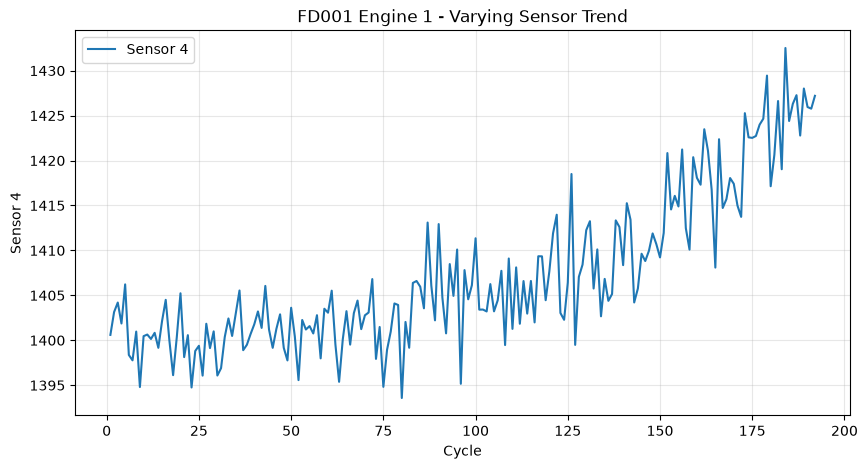

In [9]:
engine_1 = train_fd001[train_fd001["unit"] == 1]

plt.figure(figsize=(10, 5))
plt.plot(engine_1["cycle"], engine_1["sensor_4"], label="Sensor 4")
plt.xlabel("Cycle")
plt.ylabel("Sensor 4")
plt.title("FD001 Engine 1 - Varying Sensor Trend")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
